# ROC-Based Predictive Analysis: 30-Day Price Movement Classification

This notebook implements a data science workflow to predict 30-day price movements using Rate of Change (ROC) indicator.

**Objective:** Create a binary classification target where:
- `1` = Positive ROC (price increase over 30 days)
- `0` = Non-positive ROC (price stagnation or decrease over 30 days)

**Methodology:** Industry-standard exploratory data analysis, feature engineering, and data validation.

## Initial imports and basic settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [29]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}' if abs(x) < 10000 else f'{x:.0f}')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## Load data created by data pipeline

Loads the dataset and cleans from N/A values created by the pipeline

In [30]:
df = pd.read_csv('../with_indicators.csv', parse_dates=['Date'])

print(f"Total N/A values before cleaning: {df.isna().sum().sum()}")
df.dropna(inplace=True)
print(f"Total N/A values after cleaning: {df.isna().sum().sum()}")

# Add y value
df['ROC'] = df['ROC'] * 100  # Make Roc a percentage
df['Price_Direction_30d'] = (df['ROC'] > 0).astype(int)
print(f"Target variable created: {df['Price_Direction_30d'].value_counts().to_dict()}")

df.head()

Total N/A values before cleaning: 297
Total N/A values after cleaning: 0
Target variable created: {1: 3722, 0: 2787}


,Unnamed: 0,Date,Adj Close,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_12,EMA_26,RSI,MACD,MACD_Signal,BB_Lower,BB_Mid,BB_Upper,ATR,Stoch_K,Stoch_D,OBV,CCI,ROC,Price_Direction_30d
49,49,1999-04-05,0.0380,0.0414,0.0432,0.0411,0.0422,98640000,0.0429,0.0426,0.0425,0.0426,50.3047,-0.0001,0.0000,0.0394,0.0429,0.0465,0.0029,59.0079,60.6463,468576000,-2430.1594,-392.8172,0
50,50,1999-04-06,0.0370,0.0404,0.0419,0.0396,0.0418,69696000,0.0427,0.0426,0.0422,0.0424,48.0056,-0.0003,-0.0000,0.0391,0.0427,0.0464,0.0029,43.7114,53.5454,398880000,-2246.2156,-746.2180,0
51,51,1999-04-07,0.0401,0.0437,0.0440,0.0404,0.0406,89280000,0.0426,0.0426,0.0424,0.0425,55.1791,-0.0001,-0.0000,0.0393,0.0426,0.0460,0.0029,48.0843,50.2679,488160000,-2462.7682,0.0000,0
52,52,1999-04-08,0.0408,0.0445,0.0458,0.0435,0.0440,130128000,0.0426,0.0426,0.0427,0.0427,56.6647,0.0001,-0.0000,0.0393,0.0426,0.0459,0.0029,61.1985,50.9981,618288000,-2537.5295,490.7181,1
53,53,1999-04-09,0.0401,0.0437,0.0448,0.0435,0.0448,48624000,0.0426,0.0427,0.0429,0.0428,54.7118,0.0001,0.0000,0.0393,0.0426,0.0459,0.0028,75.4039,61.5622,569664000,-2526.1455,980.3233,1


## Correlation analysis

We can proceed as the data is quite balanced: {1: 3722, 0: 2787}

So positive: 57%

negative: 43%


Correlation with Target (Price_Direction_30d):
Stoch_K                  0.7958
Stoch_D                  0.7696
RSI                      0.7103
ROC                      0.7054
MACD                     0.2017
MACD_Signal              0.1411
OBV                      0.0963
Close                    0.0367
CCI                      0.0308
EMA_12                   0.0248
BB_Upper                 0.0187
EMA_26                   0.0178
BB_Mid                   0.0163
SMA_20                   0.0163
BB_Lower                 0.0134
SMA_50                   0.0101
ATR                     -0.0015
Volume                  -0.0341


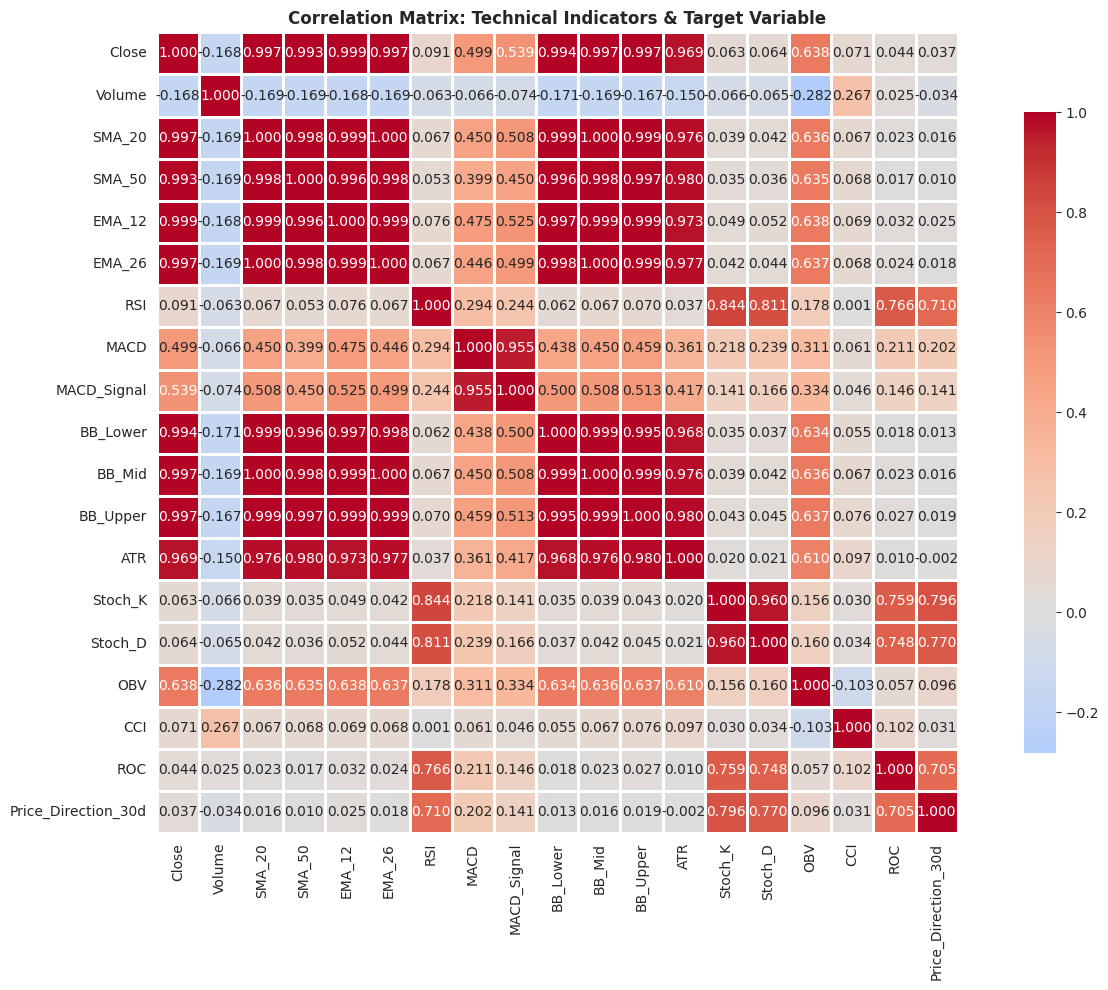

In [31]:
# Select numeric indicators for correlation analysis
numeric_cols = ['Close', 'Volume', 'SMA_20', 'SMA_50', 'EMA_12', 
                'EMA_26', 'RSI', 'MACD', 'MACD_Signal', 'BB_Lower', 
                'BB_Mid', 'BB_Upper', 'ATR', 'Stoch_K', 'Stoch_D', 
                'OBV', 'CCI', 'ROC', 'Price_Direction_30d']

correlation_matrix = df[numeric_cols].corr()

target_corr = correlation_matrix['Price_Direction_30d'].sort_values(ascending=False)
print("\nCorrelation with Target (Price_Direction_30d):")
for feature, corr_value in target_corr.items():
    if feature != 'Price_Direction_30d':
        print(f"{feature:<20} {corr_value:>10.4f}")

# Visualize correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Technical Indicators & Target Variable', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Feature Correlation Analysis

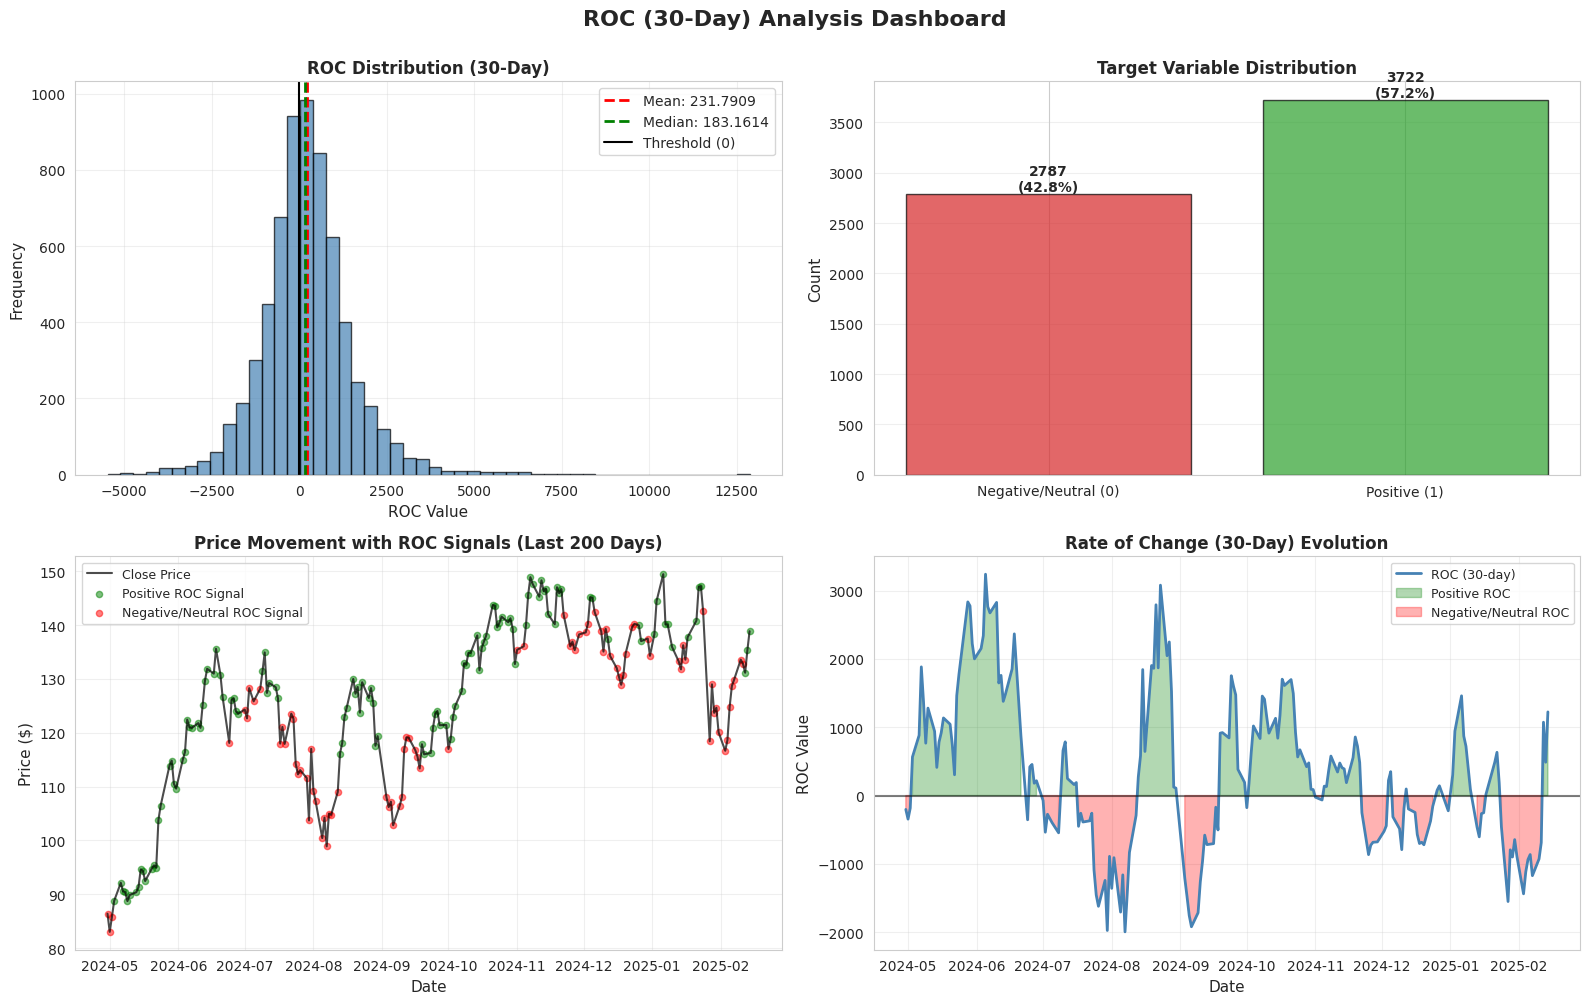

✓ Visualization complete


In [32]:
# Create comprehensive visualization dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ROC (30-Day) Analysis Dashboard', fontsize=16, fontweight='bold', y=1.00)

# 1. ROC Distribution (Histogram)
roc_data = df['ROC'].dropna()
axes[0, 0].hist(roc_data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(roc_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {roc_data.mean():.4f}')
axes[0, 0].axvline(roc_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {roc_data.median():.4f}')
axes[0, 0].axvline(0, color='black', linestyle='-', linewidth=1.5, label='Threshold (0)')
axes[0, 0].set_xlabel('ROC Value', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('ROC Distribution (30-Day)', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Class Distribution (Bar Chart)
class_dist = df['Price_Direction_30d'].value_counts().sort_index()
colors = ['#d62728', '#2ca02c']  # Red for 0 (negative), Green for 1 (positive)
bars = axes[0, 1].bar(['Negative/Neutral (0)', 'Positive (1)'], class_dist.values, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Count', fontsize=11)
axes[0, 1].set_title('Target Variable Distribution', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = (height / len(df[df['Price_Direction_30d'].notna()])) * 100
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}\n({pct:.1f}%)',
                     ha='center', va='bottom', fontweight='bold')

# 3. ROC Time Series with Signal Classification
plot_window = df.tail(200).copy()
axes[1, 0].plot(plot_window['Date'], plot_window['Close'], label='Close Price', color='black', linewidth=1.5, alpha=0.7)
# Color background by signal
positive_roc = plot_window[plot_window['Price_Direction_30d'] == 1]
negative_roc = plot_window[plot_window['Price_Direction_30d'] == 0]
axes[1, 0].scatter(positive_roc['Date'], positive_roc['Close'], color='green', alpha=0.5, s=20, label='Positive ROC Signal')
axes[1, 0].scatter(negative_roc['Date'], negative_roc['Close'], color='red', alpha=0.5, s=20, label='Negative/Neutral ROC Signal')
axes[1, 0].set_xlabel('Date', fontsize=11)
axes[1, 0].set_ylabel('Price ($)', fontsize=11)
axes[1, 0].set_title('Price Movement with ROC Signals (Last 200 Days)', fontweight='bold')
axes[1, 0].legend(loc='best', fontsize=9)
axes[1, 0].grid(alpha=0.3)

# 4. ROC Time Series
axes[1, 1].plot(plot_window['Date'], plot_window['ROC'], label='ROC (30-day)', color='steelblue', linewidth=2)
axes[1, 1].axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.5)
axes[1, 1].fill_between(plot_window['Date'], plot_window['ROC'], 0, 
                         where=(plot_window['ROC'] > 0), color='green', alpha=0.3, label='Positive ROC')
axes[1, 1].fill_between(plot_window['Date'], plot_window['ROC'], 0, 
                         where=(plot_window['ROC'] <= 0), color='red', alpha=0.3, label='Negative/Neutral ROC')
axes[1, 1].set_xlabel('Date', fontsize=11)
axes[1, 1].set_ylabel('ROC Value', fontsize=11)
axes[1, 1].set_title('Rate of Change (30-Day) Evolution', fontweight='bold')
axes[1, 1].legend(loc='best', fontsize=9)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

## 6. Visualization - ROC Distribution & Target Variable

In [33]:
# Analyze temporal patterns of ROC signals
print("=" * 80)
print("TEMPORAL ANALYSIS: ROC SIGNAL CONSISTENCY")
print("=" * 80)

# Extract year for temporal analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Signal consistency by year
print("\nClass Distribution by Year:")
print(pd.crosstab(df['Year'], df['Price_Direction_30d'], normalize='index') * 100)

# Signal consistency by month (overall trend)
print("\nClass Distribution by Month (Overall):")
monthly_signal = pd.crosstab(df['Month'], df['Price_Direction_30d'], normalize='index') * 100
print(monthly_signal)

# Identify consecutive signals
df['Signal'] = df['Price_Direction_30d'].ffill()
signal_changes = (df['Price_Direction_30d'] != df['Price_Direction_30d'].shift()).sum()

print(f"\nSignal Behavior Metrics:")
print(f"{'Total signal changes':<35} {signal_changes}")
print(f"{'Average consecutive periods':<35} {len(df) / (signal_changes + 1):.1f} days")

TEMPORAL ANALYSIS: ROC SIGNAL CONSISTENCY

Class Distribution by Year:
Price_Direction_30d       0       1
Year                               
1999                43.6842 56.3158
2000                49.2063 50.7937
2001                33.4677 66.5323
2002                69.4444 30.5556
2003                44.4444 55.5556
2004                48.8095 51.1905
2005                41.2698 58.7302
2006                29.0837 70.9163
2007                39.8406 60.1594
2008                60.8696 39.1304
2009                40.8730 59.1270
2010                50.0000 50.0000
2011                56.7460 43.2540
2012                57.6000 42.4000
2013                40.0794 59.9206
2014                43.6508 56.3492
2015                36.9048 63.0952
2016                25.7937 74.2063
2017                31.0757 68.9243
2018                48.2072 51.7928
2019                28.9683 71.0317
2020                27.6680 72.3320
2021                36.9048 63.0952
2022                62.1514 3

## 5. ROC Temporal Analysis - Signal Consistency

In [34]:
# Create binary target variable based on ROC sign
# Target encoding:
#   1 = Positive ROC (bullish signal - price increase expected over 30 days)
#   0 = Non-positive ROC (bearish/neutral signal - price stable or declining)

df['Price_Direction_30d'] = (df['ROC'] > 0).astype(int)

print("=" * 80)
print("TARGET VARIABLE CREATION: PRICE_DIRECTION_30D")
print("=" * 80)

# Calculate class distribution
class_counts = df['Price_Direction_30d'].value_counts().sort_index()
class_pct = df['Price_Direction_30d'].value_counts(normalize=True).sort_index() * 100

print(f"\nClass Distribution:")
print(f"{'Class':<30} {'Count':<15} {'Percentage':<15}")
print("-" * 60)
print(f"{'0 (Non-positive ROC)':<30} {class_counts[0]:<15} {class_pct[0]:<14.2f}%")
print(f"{'1 (Positive ROC)':<30} {class_counts[1]:<15} {class_pct[1]:<14.2f}%")

# Check for class imbalance
imbalance_ratio = max(class_pct) / min(class_pct)
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1")
print("(Values close to 1.0 indicate balanced classes; >2.0 indicates significant imbalance)")

# Identify valid samples (rows with non-NaN ROC for modeling)
valid_samples = df['Price_Direction_30d'].notna().sum()
invalid_samples = df['Price_Direction_30d'].isna().sum()

print(f"\nData Quality:")
print(f"{'Valid samples for modeling':<35} {valid_samples}")
print(f"{'Invalid samples (NaN ROC)':<35} {invalid_samples}")
print(f"{'Data completeness':<35} {(valid_samples/len(df))*100:.2f}%")

TARGET VARIABLE CREATION: PRICE_DIRECTION_30D

Class Distribution:
Class                          Count           Percentage     
------------------------------------------------------------
0 (Non-positive ROC)           2787            42.82         %
1 (Positive ROC)               3722            57.18         %

Class Imbalance Ratio: 1.34:1
(Values close to 1.0 indicate balanced classes; >2.0 indicates significant imbalance)

Data Quality:
Valid samples for modeling          6509
Invalid samples (NaN ROC)           0
Data completeness                   100.00%


## 4. Target Variable Creation - Binary Classification

In [35]:
# Statistical analysis of 30-day Rate of Change
print("=" * 80)
print("ROC (30-DAY) STATISTICAL ANALYSIS")
print("=" * 80)

# Remove NaN values for ROC statistics (first 30 rows will be NaN)
roc_clean = df['ROC'].dropna()

print(f"\nTotal ROC observations (excluding NaN): {len(roc_clean)}")
print(f"\nDescriptive Statistics:")
print(roc_clean.describe())

print(f"\n{'Metric':<25} {'Value':<15}")
print("-" * 40)
print(f"{'Mean':<25} {roc_clean.mean():<15.4f}")
print(f"{'Median':<25} {roc_clean.median():<15.4f}")
print(f"{'Std Dev':<25} {roc_clean.std():<15.4f}")
print(f"{'Skewness':<25} {roc_clean.skew():<15.4f}")
print(f"{'Kurtosis':<25} {roc_clean.kurtosis():<15.4f}")
print(f"{'Min':<25} {roc_clean.min():<15.4f}")
print(f"{'Max':<25} {roc_clean.max():<15.4f}")
print(f"{'IQR':<25} {roc_clean.quantile(0.75) - roc_clean.quantile(0.25):<15.4f}")

ROC (30-DAY) STATISTICAL ANALYSIS

Total ROC observations (excluding NaN): 6509

Descriptive Statistics:
count    6509.0000
mean      231.7909
std      1310.9984
min     -5471.2797
25%      -483.6276
50%       183.1614
75%       883.2338
max          12874
Name: ROC, dtype: float64

Metric                    Value          
----------------------------------------
Mean                      231.7909       
Median                    183.1614       
Std Dev                   1310.9984      
Skewness                  0.7041         
Kurtosis                  4.5893         
Min                       -5471.2797     
Max                       12873.5153     
IQR                       1366.8614      


## 8. Random Forest Classifier - Model Training & Evaluation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, roc_auc_score, confusion_matrix, 
                              classification_report, roc_curve, auc)

# Prepare features and target variable
# Exclude non-feature columns: Date, Year, Month, Signal, Close, Price_Direction_30d
feature_cols = ['Volume', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'RSI', 
                'MACD', 'MACD_Signal', 'BB_Lower', 'BB_Mid', 'BB_Upper', 
                'ATR', 'Stoch_K', 'Stoch_D', 'OBV', 'CCI']

X = df[feature_cols]
y = df['Price_Direction_30d']

print("=" * 80)
print("DATA PREPARATION FOR RANDOM FOREST")
print("=" * 80)
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features used: {len(feature_cols)}")
print(f"Training samples: {len(df)}")

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, 
                                                      stratify=y)

print(f"\nTrain/Test Split:")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True) * 100}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True) * 100}")


KeyError: 'Price_Direction_30d'

In [ ]:
# Train Random Forest Classifier
print("=" * 80)
print("RANDOM FOREST MODEL TRAINING")
print("=" * 80)

# Initialize Random Forest with optimized hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=100,           # Number of trees
    max_depth=15,               # Maximum depth of trees
    min_samples_split=10,       # Minimum samples to split
    min_samples_leaf=5,         # Minimum samples in leaf
    random_state=42,
    n_jobs=-1,                  # Use all processors
    class_weight='balanced'     # Handle class imbalance
)

# Train the model
print("\nTraining Random Forest with 100 trees...")
rf_model.fit(X_train, y_train)
print("✓ Model training complete")

# Make predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n✓ Predictions generated")


In [ ]:
# Model Evaluation
print("=" * 80)
print("MODEL PERFORMANCE METRICS")
print("=" * 80)

# Training metrics
train_accuracy = accuracy_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train)
train_recall = recall_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train)

# Testing metrics
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'Metric':<20} {'Training':<15} {'Testing':<15}")
print("-" * 50)
print(f"{'Accuracy':<20} {train_accuracy:<15.4f} {test_accuracy:<15.4f}")
print(f"{'Precision':<20} {train_precision:<15.4f} {test_precision:<15.4f}")
print(f"{'Recall':<20} {train_recall:<15.4f} {test_recall:<15.4f}")
print(f"{'F1-Score':<20} {train_f1:<15.4f} {test_f1:<15.4f}")
print(f"{'ROC-AUC':<20} {'N/A':<15} {test_roc_auc:<15.4f}")

# Classification report
print("\n" + "=" * 80)
print("DETAILED CLASSIFICATION REPORT (Test Set)")
print("=" * 80)
print(classification_report(y_test, y_pred_test, target_names=['Negative/Neutral', 'Positive']))

# Check for overfitting
print("\n" + "=" * 80)
print("OVERFITTING ANALYSIS")
print("=" * 80)
overfitting_gap = train_accuracy - test_accuracy
print(f"Accuracy gap (Train - Test): {overfitting_gap:.4f}")
if abs(overfitting_gap) < 0.05:
    print("✓ Minimal overfitting detected")
elif abs(overfitting_gap) < 0.10:
    print("⚠ Moderate overfitting detected")
else:
    print("⚠ Significant overfitting detected")


In [ ]:
# Feature Importance Analysis
print("=" * 80)
print("FEATURE IMPORTANCE")
print("=" * 80)

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Visualize feature importance
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top 10 features bar plot
axes[0].barh(feature_importance.head(10)['Feature'], feature_importance.head(10)['Importance'], color='steelblue')
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Top 10 Most Important Features', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()

# Cumulative importance plot
cumsum_importance = feature_importance['Importance'].cumsum()
axes[1].plot(range(1, len(cumsum_importance) + 1), cumsum_importance.values, marker='o', linestyle='-', linewidth=2)
axes[1].axhline(0.95, color='red', linestyle='--', label='95% Cumulative Importance')
axes[1].set_xlabel('Number of Features', fontsize=11)
axes[1].set_ylabel('Cumulative Importance', fontsize=11)
axes[1].set_title('Cumulative Feature Importance', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Find number of features for 95% importance
n_features_95 = (cumsum_importance >= 0.95).argmax() + 1
print(f"\nNumber of features for 95% cumulative importance: {n_features_95}")


In [ ]:
# Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Negative/Neutral', 'Positive'],
            yticklabels=['Negative/Neutral', 'Positive'])
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_title('Confusion Matrix (Test Set)', fontweight='bold', fontsize=12)

# Add metrics on confusion matrix
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.25, f'TN={tn} FP={fp}\nFN={fn} TP={tp}', 
            transform=axes[0].transAxes, ha='center', fontsize=10, family='monospace')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve (Test Set)', fontweight='bold', fontsize=12)
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Confusion matrix and ROC curve visualization complete")


In [ ]:
# Model Summary and Recent Predictions
print("=" * 80)
print("MODEL SUMMARY & PREDICTIONS")
print("=" * 80)

# Create predictions dataframe with recent test dates
predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_test,
    'Probability': y_pred_proba,
    'Correct': y_test.values == y_pred_test
})

print(f"\nTotal Test Predictions: {len(predictions_df)}")
print(f"Correct Predictions: {predictions_df['Correct'].sum()}")
print(f"Incorrect Predictions: {(~predictions_df['Correct']).sum()}")

# Show recent predictions
print("\nRecent Predictions (Last 10 samples):")
print(predictions_df.tail(10).to_string())

# Prediction confidence analysis
print("\n" + "=" * 80)
print("PREDICTION CONFIDENCE ANALYSIS")
print("=" * 80)
high_confidence = (predictions_df['Probability'] >= 0.7) | (predictions_df['Probability'] <= 0.3)
print(f"\nHigh Confidence Predictions (prob >= 0.7 or <= 0.3): {high_confidence.sum()} ({high_confidence.sum()/len(predictions_df)*100:.1f}%)")
print(f"Low Confidence Predictions (0.3 < prob < 0.7): {(~high_confidence).sum()} ({(~high_confidence).sum()/len(predictions_df)*100:.1f}%)")

print("\n✓ Random Forest model complete!")
print("\n" + "=" * 80)
print("KEY TAKEAWAYS")
print("=" * 80)
print(f"• Model Accuracy: {test_accuracy:.2%}")
print(f"• ROC-AUC Score: {test_roc_auc:.4f}")
print(f"• Top Predictor: {feature_importance.iloc[0]['Feature']} (importance: {feature_importance.iloc[0]['Importance']:.4f})")
print(f"• Class Balance: {y_test.value_counts(normalize=True)[1]:.1%} positive signals in test set")
print("=" * 80)
